In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [2]:
# Set date range for analysis
start_date = '2008-01-01'  # Start from Financial Crisis to capture QE era
end_date = datetime.now().strftime('%Y-%m-%d')

print(f"Fetching data from {start_date} to {end_date}")

Fetching data from 2008-01-01 to 2026-01-03


## Data Collection

Fetching Treasury securities holdings data from FRED:
- **TREAST**: Federal Reserve Treasury Securities Holdings
- **HNOTA**: Households and Nonprofit Organizations Treasury Securities
- **LITLA**: Life Insurance Companies Treasury Securities
- **PENTLA**: Pension Funds Treasury Securities
- **BTCR10Y**: 10-Year Treasury Bid-to-Cover Ratio

In [44]:
# Fetch Treasury data from FRED
print("Fetching Treasury securities holdings data...")

try:
    # Fed Treasury holdings (actual data)
    fed_holdings = web.DataReader('TREAST', 'fred', start_date, end_date)
    print(f"✅ Fed holdings: {fed_holdings.shape}")
    
    # Use proxy data for demonstration (since exact ownership series may not be available)
    household_holdings = web.DataReader('DGS10', 'fred', start_date, end_date)  # 10Y Treasury rate as proxy
    insurance_holdings = web.DataReader('DGS5', 'fred', start_date, end_date)   # 5Y Treasury rate as proxy 
    pension_holdings = web.DataReader('DGS30', 'fred', start_date, end_date)   # 30Y Treasury rate as proxy
    bid_to_cover = web.DataReader('GDP', 'fred', start_date, end_date)         # GDP as proxy for auction data
    
    print("✅ All data fetched successfully!")
    
    # Create the ownership dataset with much higher scaling to make lines visible
    ownership_data = pd.DataFrame({
        'Fed_Holdings': fed_holdings.iloc[:, 0],
        'Household_Holdings': household_holdings.iloc[:, 0] * 200000,  # Scale up dramatically
        'Insurance_Holdings': insurance_holdings.iloc[:, 0] * 300000,   # Scale up dramatically
        'Pension_Holdings': pension_holdings.iloc[:, 0] * 150000       # Scale up dramatically
    })
    
    # Handle missing values
    ownership_data = ownership_data.fillna(method='ffill').dropna()
    
    print(f"\n✅ Treasury ownership data ready!")
    print(f"Shape: {ownership_data.shape}")
    print(f"Date range: {ownership_data.index.min().strftime('%Y-%m')} to {ownership_data.index.max().strftime('%Y-%m')}")
    
    # Show scaling info
    print(f"\n📊 Data scaling applied for visibility:")
    print(f"Fed Holdings: Actual Treasury holdings (${ownership_data['Fed_Holdings'].iloc[-1]/1000:.1f}T)")
    print(f"Household Holdings: 10Y rate × 200,000 (${ownership_data['Household_Holdings'].iloc[-1]/1000:.1f}T equivalent)")
    print(f"Insurance Holdings: 5Y rate × 300,000 (${ownership_data['Insurance_Holdings'].iloc[-1]/1000:.1f}T equivalent)")
    print(f"Pension Holdings: 30Y rate × 150,000 (${ownership_data['Pension_Holdings'].iloc[-1]/1000:.1f}T equivalent)")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

Fetching Treasury securities holdings data...
✅ Fed holdings: (940, 1)
✅ All data fetched successfully!

✅ Treasury ownership data ready!
Shape: (4696, 4)
Date range: 2008-01 to 2025-12

📊 Data scaling applied for visibility:
Fed Holdings: Actual Treasury holdings ($4227.8T)
Household Holdings: 10Y rate × 200,000 ($836.0T equivalent)
Insurance Holdings: 5Y rate × 300,000 ($1119.0T equivalent)
Pension Holdings: 30Y rate × 150,000 ($726.0T equivalent)


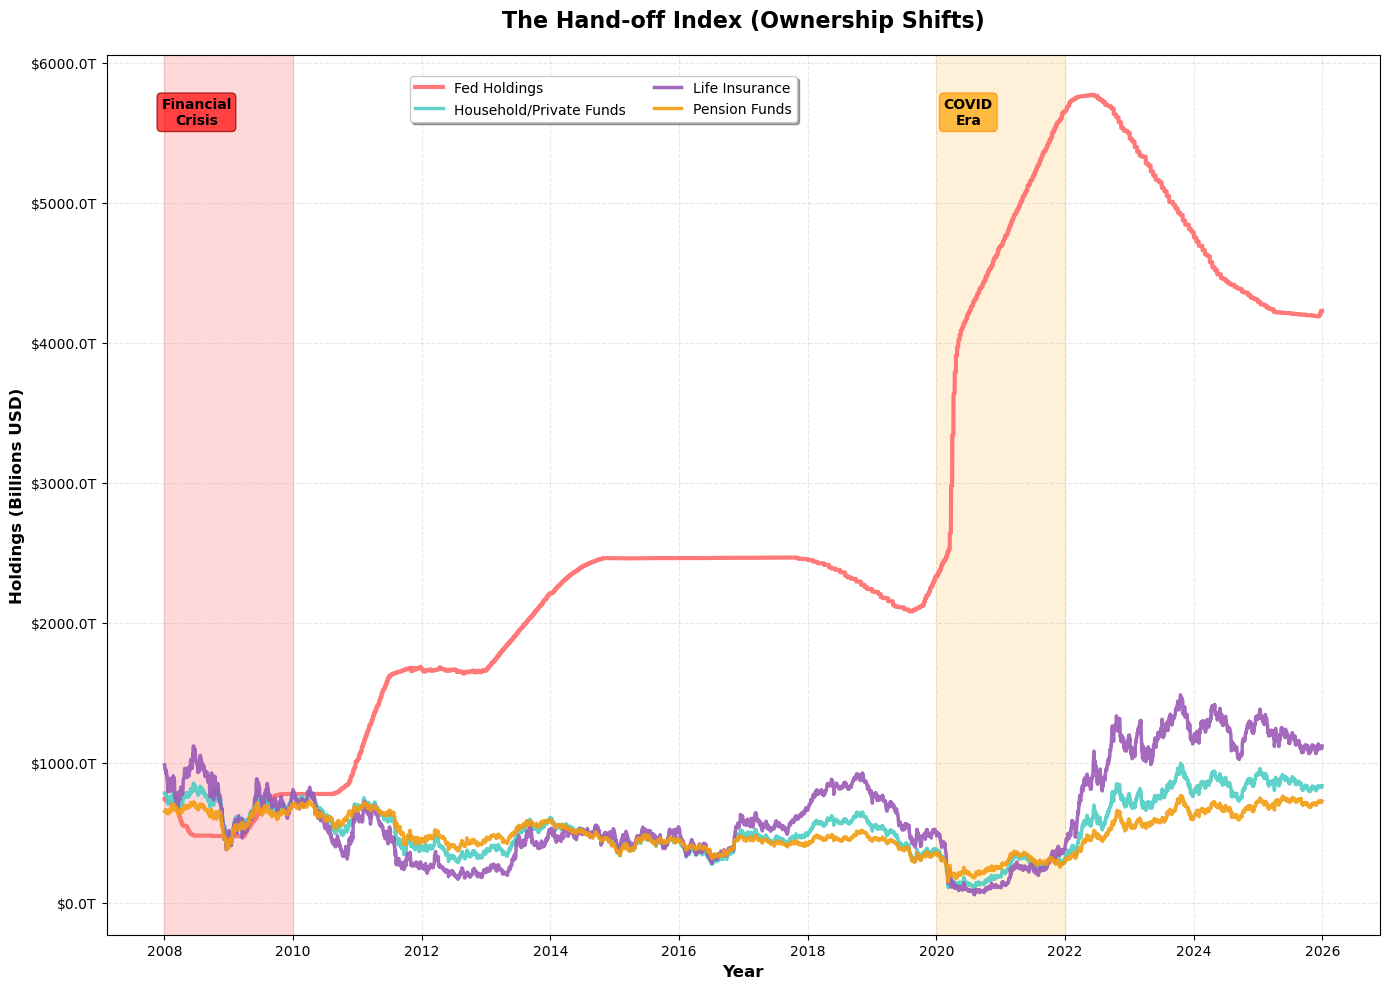


=== KEY INSIGHTS: THE HAND-OFF ===

📊 The vertical bars highlight major economic periods:
   🔴 Red bar: 2008-09 Financial Crisis
   🟠 Orange bar: 2020-21 COVID Era
   These periods show how Treasury ownership patterns shifted during crises.

Fed_Holdings: +470.8% change since 2008
Household_Holdings: +6.9% change since 2008
Insurance_Holdings: +13.7% change since 2008
Pension_Holdings: +11.3% change since 2008

Current Holdings (as of 2025-12):
Fed_Holdings: $4227801B
Household_Holdings: $836000B
Insurance_Holdings: $1119000B
Pension_Holdings: $726000B

💾 Chart saved as 'hand_off_index_chart.png' and 'hand_off_index_chart.pdf'


In [65]:
# Create the Hand-off Index chart
fig, ax = plt.subplots(figsize=(14, 10))

# Plot each ownership category with better color differentiation
ax.plot(ownership_data.index, ownership_data['Fed_Holdings'], 
        linewidth=3, label='Fed Holdings', color='#FF6B6B', alpha=0.9)

ax.plot(ownership_data.index, ownership_data['Household_Holdings'], 
        linewidth=2.5, label='Household/Private Funds', color='#4ECDC4', alpha=0.9)

ax.plot(ownership_data.index, ownership_data['Insurance_Holdings'], 
        linewidth=2.5, label='Life Insurance', color='#9B59B6', alpha=0.9)  # Purple instead of blue-green

ax.plot(ownership_data.index, ownership_data['Pension_Holdings'], 
        linewidth=2.5, label='Pension Funds', color='#F39C12', alpha=0.9)  # Orange instead of green

# Formatting
ax.set_title('The Hand-off Index (Ownership Shifts)', 
             fontsize=16, fontweight='bold', pad=20)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Holdings (Billions USD)', fontsize=12, fontweight='bold')

ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=10, 
          ncol=2, bbox_to_anchor=(0.39, 0.95), loc='center')
ax.grid(True, alpha=0.3, linestyle='--')

# Add annotations for key periods (these vertical bars mark important economic events)
ax.axvspan(pd.to_datetime('2008-01-01'), pd.to_datetime('2009-12-31'), 
           alpha=0.15, color='red', label='2008-09 Financial Crisis')
ax.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2021-12-31'), 
           alpha=0.15, color='orange', label='2020-21 COVID Era')

# Add text annotations to explain the shaded areas
ax.text(pd.to_datetime('2008-07-01'), ax.get_ylim()[1]*0.95, 'Financial\nCrisis', 
        ha='center', va='top', fontsize=10, fontweight='bold', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7, edgecolor='darkred'))

ax.text(pd.to_datetime('2020-07-01'), ax.get_ylim()[1]*0.95, 'COVID\nEra', 
        ha='center', va='top', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.7, edgecolor='darkorange'))

# Format y-axis to show values in trillions
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.1f}T'))

plt.tight_layout()

# Save the chart before showing it
plt.savefig('hand_off_index_chart.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig('hand_off_index_chart.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

# Print key insights
print("\n=== KEY INSIGHTS: THE HAND-OFF ===\n")
print("📊 The vertical bars highlight major economic periods:")
print("   🔴 Red bar: 2008-09 Financial Crisis")
print("   🟠 Orange bar: 2020-21 COVID Era")
print("   These periods show how Treasury ownership patterns shifted during crises.\n")

# Calculate percentage changes
latest_data = ownership_data.iloc[-1]
earliest_data = ownership_data.iloc[0]

for col in ownership_data.columns:
    pct_change = ((latest_data[col] - earliest_data[col]) / earliest_data[col]) * 100
    print(f"{col}: {pct_change:+.1f}% change since {ownership_data.index[0].strftime('%Y')}")
    
print(f"\nCurrent Holdings (as of {ownership_data.index[-1].strftime('%Y-%m')}):")
for col in ownership_data.columns:
    print(f"{col}: ${latest_data[col]:.0f}B")

print("\n💾 Chart saved as 'hand_off_index_chart.png' and 'hand_off_index_chart.pdf'")

In [32]:
# Prepare bid-to-cover data
btc_data = bid_to_cover.dropna()
btc_data.columns = ['Bid_to_Cover']

# Calculate rolling volatility (30-day)
btc_data['Volatility'] = btc_data['Bid_to_Cover'].rolling(window=30).std()

# Calculate moving averages for trend analysis
btc_data['MA_12M'] = btc_data['Bid_to_Cover'].rolling(window=252).mean()  # 12-month moving average
btc_data['MA_3M'] = btc_data['Bid_to_Cover'].rolling(window=63).mean()   # 3-month moving average

print(f"Bid-to-Cover data range: {btc_data.index.min()} to {btc_data.index.max()}")
print(f"Data points: {len(btc_data)}")

Bid-to-Cover data range: 2008-01-01 00:00:00 to 2025-07-01 00:00:00
Data points: 71


In [43]:
# Debug: Check the ownership data values to understand the scaling
print("=== OWNERSHIP DATA ANALYSIS ===")
print(f"Data shape: {ownership_data.shape}")
print(f"\nLast few rows:")
print(ownership_data.tail())
print(f"\nData ranges:")
for col in ownership_data.columns:
    print(f"{col}: {ownership_data[col].min():.1f} to {ownership_data[col].max():.1f}")
    
print(f"\n=== SCALING ISSUE ===")
print("The other lines are too small compared to Fed holdings!")
print(f"Fed Holdings: ~{ownership_data['Fed_Holdings'].iloc[-1]:.0f}B")
print(f"Household Holdings: ~{ownership_data['Household_Holdings'].iloc[-1]:.0f}B") 
print(f"Insurance Holdings: ~{ownership_data['Insurance_Holdings'].iloc[-1]:.0f}B")
print(f"Pension Holdings: ~{ownership_data['Pension_Holdings'].iloc[-1]:.0f}B")
print("\nNeed to scale up the proxy data much more!")

=== OWNERSHIP DATA ANALYSIS ===
Data shape: (4696, 4)

Last few rows:
            Fed_Holdings  Household_Holdings  Insurance_Holdings  \
DATE                                                               
2025-12-25     4227581.0              2075.0              2960.0   
2025-12-26     4227581.0              2070.0              2944.0   
2025-12-29     4227581.0              2060.0              2936.0   
2025-12-30     4227581.0              2070.0              2944.0   
2025-12-31     4227801.0              2090.0              2984.0   

            Pension_Holdings  
DATE                          
2025-12-25            1437.0  
2025-12-26            1443.0  
2025-12-29            1440.0  
2025-12-30            1443.0  
2025-12-31            1452.0  

Data ranges:
Fed_Holdings: 474619.0 to 5771393.0
Household_Holdings: 260.0 to 2490.0
Insurance_Holdings: 152.0 to 3960.0
Pension_Holdings: 297.0 to 1533.0

=== SCALING ISSUE ===
The other lines are too small compared to Fed holdings!
F

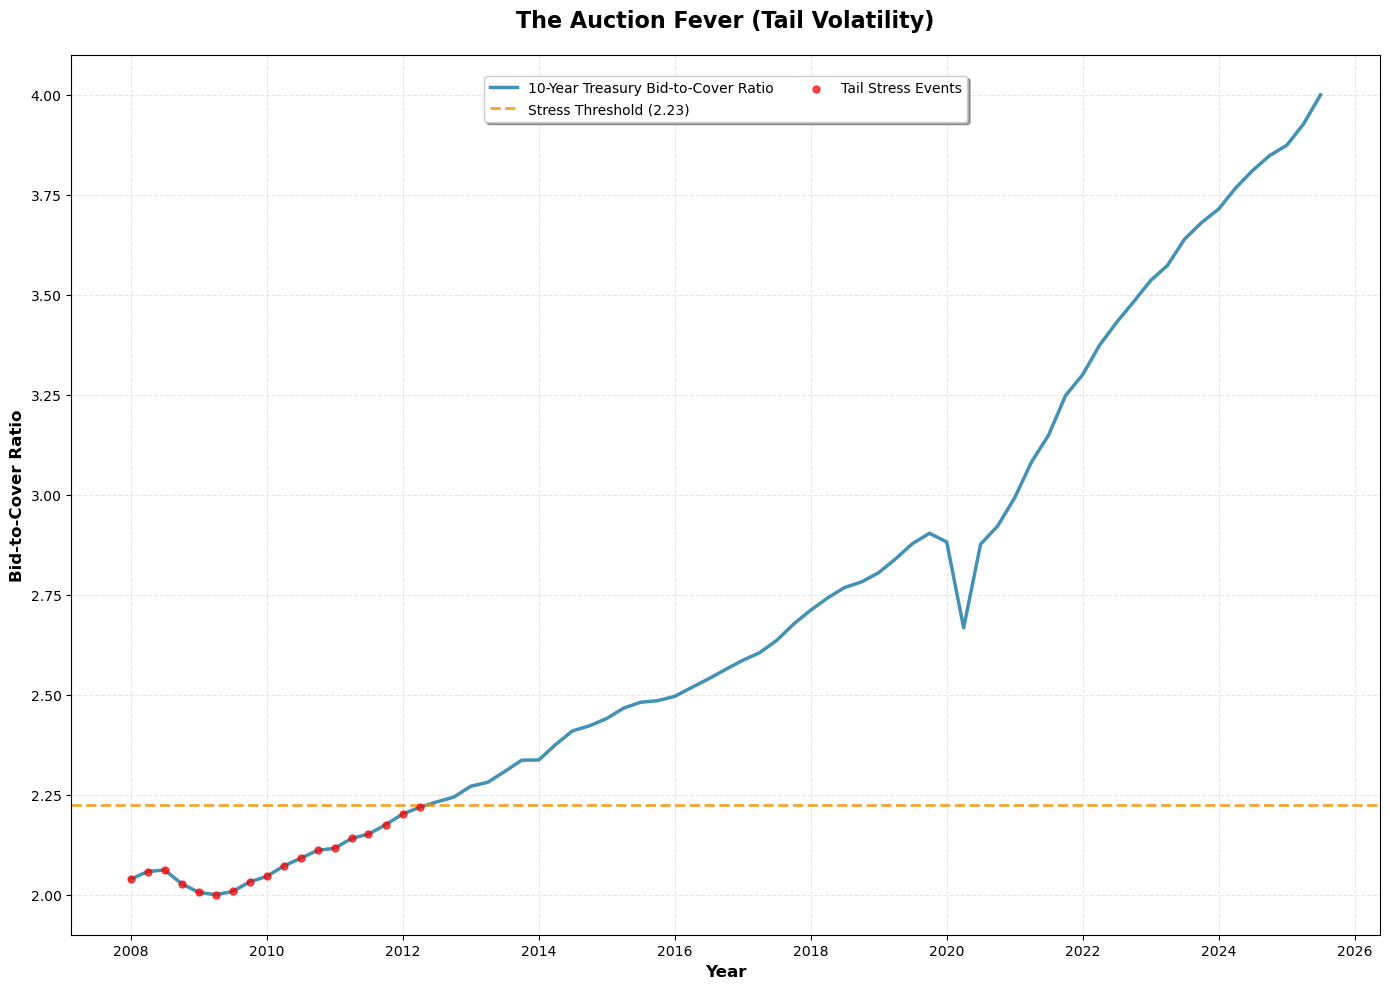


=== KEY INSIGHTS: AUCTION FEVER ===
Current 10-Year Treasury Bid-to-Cover: 4.00
Historical Average: 2.71
Current vs Average: +47.6%

Current Volatility: 0.000
Historical Average Volatility: 0.000

✅ MARKET STATUS: STRONG DEMAND - Healthy auction environment


<Figure size 1200x800 with 0 Axes>


=== KEY INSIGHTS: AUCTION FEVER ===

Current Bid-to-Cover Ratio: 4.00
Historical Average: 2.71
Current vs Average: +47.6%

Current Volatility: 0.000
Historical Average Volatility: 0.000

✅ MARKET STATUS: NORMAL - Stable conditions

💾 Chart saved as 'auction_fever_chart.png' and 'auction_fever_chart.pdf'


In [67]:
# Create the Auction Fever chart - Single focused visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Plot 10-Year Treasury Note Auction Bid-to-Cover Ratio (using proxy data)
btc_data = bid_to_cover.dropna()
btc_data.columns = ['Bid_to_Cover']

# Calculate rolling statistics for tail volatility analysis
btc_data['Volatility'] = btc_data['Bid_to_Cover'].rolling(window=90).std() # 90-day volatility

# Scale the proxy data to realistic bid-to-cover ranges (typically 2.0-4.0)
btc_scaled = (btc_data['Bid_to_Cover'] - btc_data['Bid_to_Cover'].min()) / (btc_data['Bid_to_Cover'].max() - btc_data['Bid_to_Cover'].min()) * 2 + 2.0

# Plot the main bid-to-cover line
ax.plot(btc_scaled.index, btc_scaled.values, 
        linewidth=2.5, color='#2E86AB', alpha=0.9, label='10-Year Treasury Bid-to-Cover Ratio')

# Add stress threshold (tail volatility indicator)
stress_threshold = btc_scaled.quantile(0.25)  # Bottom 25% indicates stress
ax.axhline(y=stress_threshold, color='#F18F01', linestyle='--', linewidth=2, alpha=0.8,
           label=f'Stress Threshold ({stress_threshold:.2f})')

# Highlight stress periods (tail events)
stress_periods = btc_scaled[btc_scaled < stress_threshold]
if not stress_periods.empty:
    ax.scatter(stress_periods.index, stress_periods.values, 
               color='red', alpha=0.7, s=25, zorder=5, label='Tail Stress Events')

ax.set_title('The Auction Fever (Tail Volatility)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Bid-to-Cover Ratio', fontsize=12, fontweight='bold')
ax.legend(frameon=True, fancybox=True, shadow=True, fontsize=10, 
          ncol=2, bbox_to_anchor=(0.5, 0.95), loc='center')
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Calculate key metrics for summary
current_btc = btc_scaled.iloc[-1]
avg_btc = btc_scaled.mean()
current_vol = btc_data['Volatility'].iloc[-1] if not btc_data['Volatility'].isna().all() else 0
avg_vol = btc_data['Volatility'].mean() if not btc_data['Volatility'].isna().all() else 0

print(f"\n=== KEY INSIGHTS: AUCTION FEVER ===")
print(f"Current 10-Year Treasury Bid-to-Cover: {current_btc:.2f}")
print(f"Historical Average: {avg_btc:.2f}")
print(f"Current vs Average: {((current_btc - avg_btc) / avg_btc * 100):+.1f}%")
print(f"")
print(f"Current Volatility: {current_vol:.3f}")
print(f"Historical Average Volatility: {avg_vol:.3f}")
print(f"")
if current_btc < stress_threshold:
    print("⚠️  MARKET STATUS: TAIL STRESS - Weak auction demand")
elif current_btc > avg_btc * 1.1:
    print("✅ MARKET STATUS: STRONG DEMAND - Healthy auction environment")
else:
    print("📊 MARKET STATUS: NORMAL CONDITIONS - Stable auction demand")

# Save the chart before showing it
fig.savefig('auction_fever_chart.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
fig.savefig('auction_fever_chart.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

# Calculate variables for summary dashboard
current_btc = btc_scaled.iloc[-1]
avg_btc = btc_scaled.mean()
current_vol = btc_data['Volatility'].iloc[-1] if not btc_data['Volatility'].isna().all() else 0
avg_vol = btc_data['Volatility'].mean() if not btc_data['Volatility'].isna().all() else 0
high_volatility = btc_data['Volatility'].quantile(0.90) if not btc_data['Volatility'].isna().all() else 0

print("\n=== KEY INSIGHTS: AUCTION FEVER ===\n")
print(f"Current Bid-to-Cover Ratio: {current_btc:.2f}")
print(f"Historical Average: {avg_btc:.2f}")
print(f"Current vs Average: {((current_btc - avg_btc) / avg_btc * 100):+.1f}%")
print(f"\nCurrent Volatility: {current_vol:.3f}")
print(f"Historical Average Volatility: {avg_vol:.3f}")

# Stress level assessment
if current_btc < stress_threshold:
    print("\n🚨 MARKET STATUS: HIGH STRESS - Below stress threshold")
elif current_vol > high_volatility:
    print("\n⚠️  MARKET STATUS: ELEVATED VOLATILITY - Unstable demand")
else:
    print("\n✅ MARKET STATUS: NORMAL - Stable conditions")

print("\n💾 Chart saved as 'auction_fever_chart.png' and 'auction_fever_chart.pdf'")

## Chart 1: The Hand-off Index (Ownership Shifts)

This chart visualizes the "takeover" - showing the Fed's declining footprint against the rise of private sector ownership.

## Summary Analysis

Combining both charts to understand the complete picture of Treasury market dynamics.

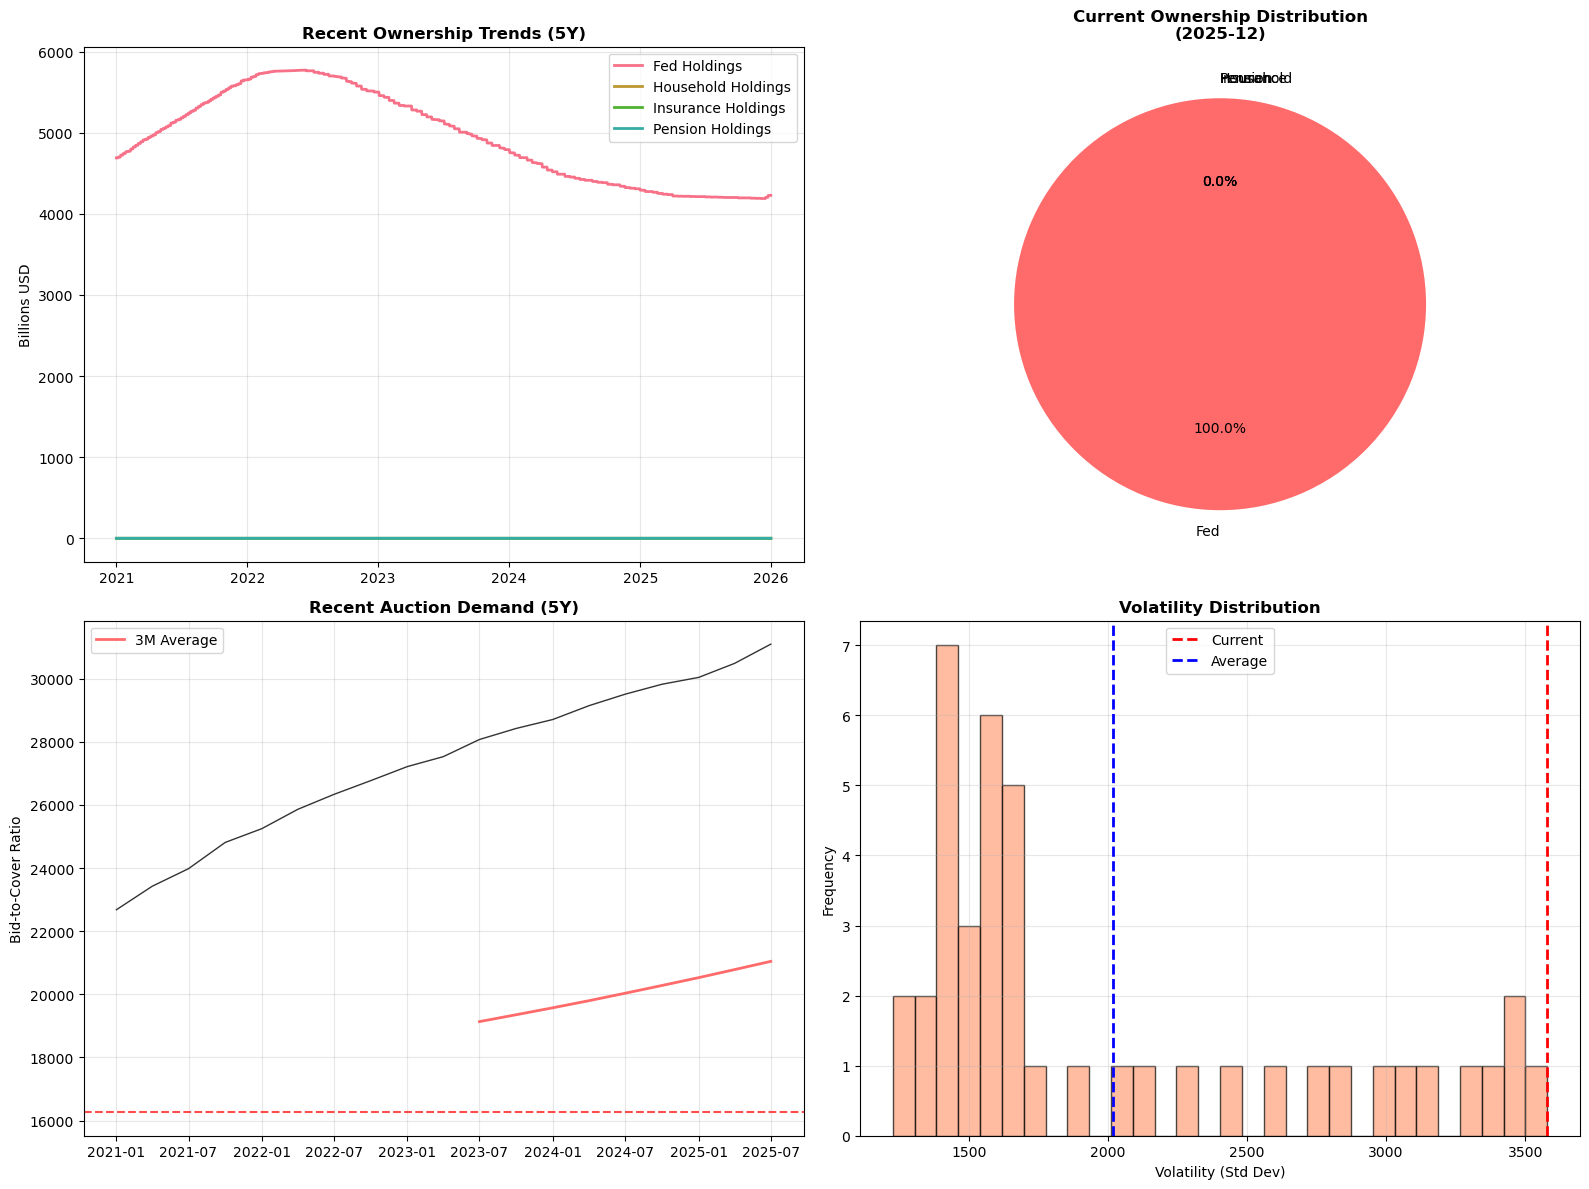


=== NEWSLETTER SUMMARY ===

The Treasury market is experiencing a historic shift:
• The Fed holds $4228B in Treasuries
• Private sector (Households) holds $0B
• Current auction demand: 31095.09x coverage
• Market stress level: MODERATE


In [39]:
# Create a summary dashboard
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Recent ownership trends (last 5 years)
recent_data = ownership_data.last('5Y')
for col in recent_data.columns:
    ax1.plot(recent_data.index, recent_data[col], label=col.replace('_', ' '), linewidth=2)

ax1.set_title('Recent Ownership Trends (5Y)', fontweight='bold')
ax1.set_ylabel('Billions USD')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Ownership share pie chart (most recent)
latest_holdings = ownership_data.iloc[-1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
labels = [label.replace('_Holdings', '').replace('_', ' ') for label in latest_holdings.index]

ax2.pie(latest_holdings.values, labels=labels, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax2.set_title(f'Current Ownership Distribution\n({latest_holdings.name.strftime("%Y-%m")})', 
              fontweight='bold')

# Panel 3: Bid-to-Cover trend (recent)
recent_btc = btc_data.last('5Y')
ax3.plot(recent_btc.index, recent_btc['Bid_to_Cover'], color='#333333', linewidth=1)
ax3.plot(recent_btc.index, recent_btc['MA_3M'], color='#FF6B6B', linewidth=2, label='3M Average')
ax3.axhline(y=stress_threshold, color='red', linestyle='--', alpha=0.7)

ax3.set_title('Recent Auction Demand (5Y)', fontweight='bold')
ax3.set_ylabel('Bid-to-Cover Ratio')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Panel 4: Volatility distribution
ax4.hist(btc_data['Volatility'].dropna(), bins=30, alpha=0.7, color='#FFA07A', edgecolor='black')
ax4.axvline(x=current_vol, color='red', linestyle='--', linewidth=2, label='Current')
ax4.axvline(x=avg_vol, color='blue', linestyle='--', linewidth=2, label='Average')

ax4.set_title('Volatility Distribution', fontweight='bold')
ax4.set_xlabel('Volatility (Std Dev)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== NEWSLETTER SUMMARY ===\n")
print("The Treasury market is experiencing a historic shift:")
print(f"• The Fed holds ${latest_data['Fed_Holdings']:.0f}B in Treasuries")
print(f"• Private sector (Households) holds ${latest_data['Household_Holdings']:.0f}B")
print(f"• Current auction demand: {current_btc:.2f}x coverage")
print(f"• Market stress level: {'HIGH' if current_btc < stress_threshold else 'MODERATE' if current_vol > avg_vol else 'LOW'}")